# Smurfing 

If your goal is to build a realistic AML prototype for structuring (smurfing) detection, I'd organize the notebook as a progression from:

Generate/load transaction data
Explore behavior
Engineer structuring features
Build statistical detectors
Build ML models
Explain alerts

In [1]:
import numpy as np
import pandas as pd

from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

In [2]:
n_customers = 1000

transactions = []

for customer_id in range(n_customers):
    # Number of transcations
    n_txns = np.random.randint(20, 100)
    # Suspicious transcations
    suspicious = np.random.rand() < 0.05

    for _ in range(n_txns):
        # Create timestamp for each transcation
        timestamp = (
            datetime(2025,1,1)
            + timedelta(days=np.random.randint(0,180))
        )

        if suspicious:
            amount = np.random.normal(9500, 400)
        else:
            amount = np.random.lognormal(
                mean=7,
                sigma=0.8
            )

        transactions.append([
            customer_id,
            timestamp,
            max(1, amount),
            int(suspicious)
        ])

df = pd.DataFrame(
    transactions,
    columns=[
        "customer_id",
        "timestamp",
        "amount",
        "label"
    ]
)

df.head()

,customer_id,timestamp,amount,label
0,0,2025-04-17,1602.129029,0
1,0,2025-05-02,3277.250536,0
2,0,2025-03-16,219.473103,0
3,0,2025-04-14,739.339530,0
4,0,2025-06-01,745.388056,0


In [4]:
# Basic EDA
df.describe()

,customer_id,timestamp,amount,label
count,59193.000000,59193,59193.000000,59193.000000
mean,496.257480,2025-03-31 08:39:01.249809,1963.579402,0.056578
min,0.000000,2025-01-01 00:00:00,30.865072,0.000000
25%,242.000000,2025-02-14 00:00:00,661.291714,0.000000
50%,494.000000,2025-03-31 00:00:00,1164.011142,0.000000
75%,749.000000,2025-05-15 00:00:00,2122.132990,0.000000
max,999.000000,2025-06-29 00:00:00,29151.854813,1.000000
std,288.549104,NaN,2315.499722,0.231036


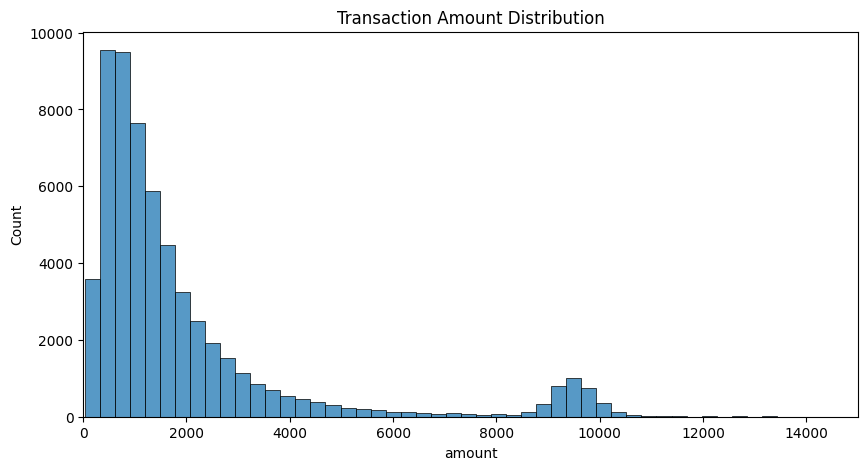

In [5]:
# Amount distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df["amount"],
    bins=100
)

plt.xlim(0,15000)
plt.title("Transaction Amount Distribution")
plt.show()

In [6]:
# Examine threshold behaviour

# Assumed reporting threshold
threshold = 10000

near_threshold = df[
    (df["amount"] > 8000) &
    (df["amount"] < threshold)
]

print(len(near_threshold))

3205


In [7]:
# Create customer-level features
features = df.groupby("customer_id").agg(
    transaction_count=("amount","count"),
    mean_amount=("amount","mean"),
    std_amount=("amount","std"),
    max_amount=("amount","max"),
    suspicious_label=("label","max")
)

features.head()

,transaction_count,mean_amount,std_amount,max_amount,suspicious_label
customer_id,,,,,
0,71,1431.307746,1425.429390,7868.271533,0
1,38,1563.813514,1191.864569,5281.829491,0
2,52,2140.089008,3434.201455,23913.183400,0
3,20,1477.446096,1043.511036,4903.009819,0
4,27,1284.702886,970.447863,4189.072381,0


In [8]:
# Near-threshold features
near_threshold_counts = (
    df.assign(
        near_threshold=lambda x:
        (
            (x["amount"] > 8000) &
            (x["amount"] < 10000)
        ).astype(int)
    )
    .groupby("customer_id")
    .agg(
        near_threshold_count=(
            "near_threshold",
            "sum"
        )
    )
)

features = features.join(
    near_threshold_counts
)

In [9]:
# Near threshold ratio
features["near_threshold_ratio"] = (
    features["near_threshold_count"]
    /
    features["transaction_count"]
)

In [10]:
# Transaction frequency features 
daily_counts = (
    df.groupby(
        [
            "customer_id",
            pd.Grouper(
                key="timestamp",
                freq="D"
            )
        ]
    )
    .size()
    .reset_index(name="daily_count")
)

daily_features = daily_counts.groupby(
    "customer_id"
).agg(
    avg_daily_txns=("daily_count","mean"),
    max_daily_txns=("daily_count","max")
)

features = features.join(
    daily_features
)

In [11]:
# Feature inspection
features.head()

,transaction_count,mean_amount,std_amount,max_amount,suspicious_label,near_threshold_count,near_threshold_ratio,avg_daily_txns,max_daily_txns
customer_id,,,,,,,,,
0,71,1431.307746,1425.429390,7868.271533,0,0,0.0,1.183333,2
1,38,1563.813514,1191.864569,5281.829491,0,0,0.0,1.187500,2
2,52,2140.089008,3434.201455,23913.183400,0,0,0.0,1.040000,2
3,20,1477.446096,1043.511036,4903.009819,0,0,0.0,1.052632,2
4,27,1284.702886,970.447863,4189.072381,0,0,0.0,1.038462,2


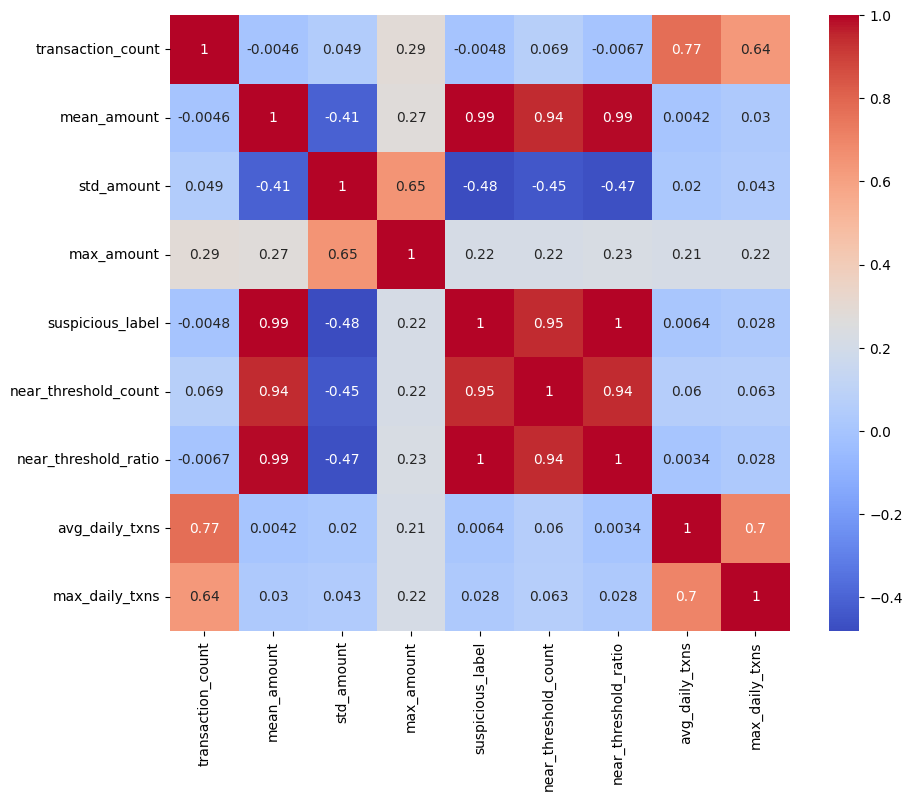

In [12]:
# Correlation analysis
plt.figure(figsize=(10,8))

sns.heatmap(
    features.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
# Statistical detector using Z-scores
from scipy.stats import zscore

features["z_near_threshold_count"] = zscore(
    features["near_threshold_count"]
)

features[
    features["z_near_threshold_count"] > 3
].head()
# Interpretation: Customers making unusually many 
# near-threshold transactions.

,transaction_count,mean_amount,std_amount,max_amount,suspicious_label,near_threshold_count,near_threshold_ratio,avg_daily_txns,max_daily_txns,z_near_threshold_count
customer_id,,,,,,,,,,
14,80,9555.300010,368.049018,10518.419333,1,73,0.912500,1.194030,3,5.442728
17,55,9438.390356,346.724713,10313.322119,1,53,0.963636,1.145833,2,3.883096
35,77,9500.231350,452.627022,10606.391846,1,68,0.883117,1.184615,3,5.052820
48,65,9533.747803,344.153574,10271.732315,1,60,0.923077,1.274510,2,4.428967
110,79,9547.852420,369.596606,10666.813108,1,70,0.886076,1.274194,4,5.208783


In [15]:
# Unsupervised anomaly detecction
anomaly_features = [
    "transaction_count",
    "mean_amount",
    "std_amount",
    "near_threshold_count",
    "near_threshold_ratio",
    "avg_daily_txns",
    "max_daily_txns"
]

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

features["anomaly_score"] = iso.fit_predict(
    features[anomaly_features]
)

features["anomaly_flag"] = (
    features["anomaly_score"] == -1
).astype(int)

In [17]:
# Review top anomalies
features.sort_values(
    "near_threshold_count",
    ascending=False
).head(20)

,transaction_count,mean_amount,std_amount,max_amount,suspicious_label,near_threshold_count,near_threshold_ratio,avg_daily_txns,max_daily_txns,z_near_threshold_count,anomaly_score,anomaly_flag
customer_id,,,,,,,,,,,,
790,92,9447.385513,380.027227,10427.746981,1,85,0.923913,1.260274,3,6.378508,-1,1
823,98,9564.434907,429.439844,10513.259331,1,83,0.846939,1.306667,3,6.222545,-1,1
130,95,9516.541091,376.040060,10337.866370,1,83,0.873684,1.338028,4,6.222545,-1,1
148,92,9477.630804,421.017256,10575.205716,1,83,0.902174,1.226667,3,6.222545,-1,1
185,93,9518.923244,418.005748,10455.231350,1,81,0.870968,1.367647,3,6.066581,-1,1
183,87,9501.712631,365.166405,10400.755981,1,79,0.908046,1.318182,5,5.910618,-1,1
14,80,9555.300010,368.049018,10518.419333,1,73,0.912500,1.194030,3,5.442728,-1,1
922,82,9536.431588,413.725899,10446.087523,1,71,0.865854,1.281250,3,5.286765,-1,1
482,76,9522.268508,373.866300,10584.580029,1,70,0.921053,1.206349,4,5.208783,-1,1


In [20]:
# Build supervised model - assumes historical SAR labels
X = features[
    [
        "transaction_count",
        "mean_amount",
        "std_amount",
        "near_threshold_count",
        "near_threshold_ratio",
        "avg_daily_txns",
        "max_daily_txns"
    ]
]

y = features["suspicious_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [21]:
# Evaluate model
preds = model.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       189
           1       1.00      1.00      1.00        11

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



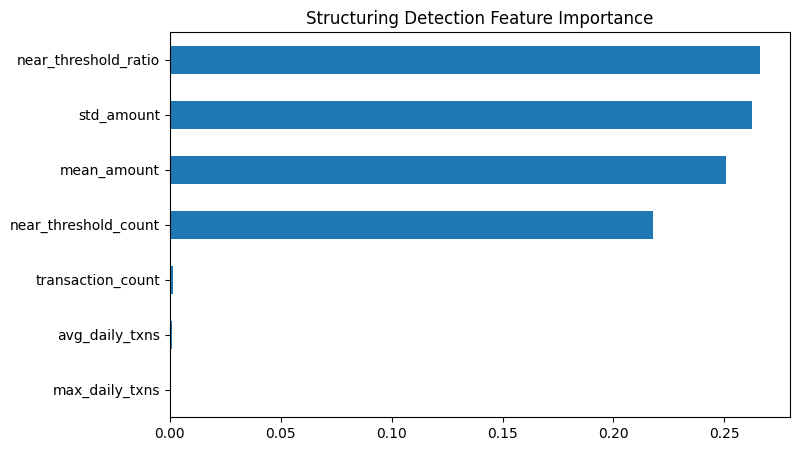

In [22]:
# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title(
    "Structuring Detection Feature Importance"
)

plt.show()

In [23]:
# Rule + ML hybrid score
features["rule_score"] = (
    0.7 * features["near_threshold_ratio"]
    +
    0.3 * (
        features["max_daily_txns"]
        /
        features["max_daily_txns"].max()
    )
)

features["ml_score"] = model.predict_proba(
    X
)[:,1]

features["final_risk_score"] = (
    0.5 * features["rule_score"]
    +
    0.5 * features["ml_score"]
)

In [24]:
# Top customers for investigation
alerts = (
    features
    .sort_values(
        "final_risk_score",
        ascending=False
    )
    .head(50)
)

alerts[
    [
        "near_threshold_count",
        "near_threshold_ratio",
        "ml_score",
        "final_risk_score"
    ]
]

,near_threshold_count,near_threshold_ratio,ml_score,final_risk_score
customer_id,,,,
183,79,0.908046,0.996667,0.966149
482,70,0.921053,1.000000,0.942368
855,48,0.888889,1.000000,0.931111
110,70,0.886076,1.000000,0.930127
71,30,0.967742,1.000000,0.928710
435,27,0.964286,1.000000,0.927500
130,83,0.873684,0.993333,0.922456
469,39,0.928571,1.000000,0.915000
229,38,0.926829,1.000000,0.914390


In [25]:
# Explain an alert
customer = alerts.index[0]

df[
    df["customer_id"] == customer
].sort_values(
    "timestamp"
).tail(50)

,customer_id,timestamp,amount,label
11008,183,2025-03-29,10353.025235,1
10982,183,2025-03-30,9691.826290,1
10961,183,2025-03-30,9132.904767,1
10952,183,2025-04-03,9500.328251,1
11018,183,2025-04-06,9097.019917,1
11012,183,2025-04-07,9674.989866,1
11011,183,2025-04-10,9700.550638,1
10946,183,2025-04-11,9328.050906,1
11021,183,2025-04-11,9628.948160,1
10949,183,2025-04-12,9478.414936,1


How to improve this:
- Rolling 7-day and 30-day windows
- Branch-level aggregation
- Cross-account linkage
- Device/IP linkage
- Graph features
- SAR feedback loops
- XGBoost or LightGBM instead of Random Forest
- SHAP explanations
- Real-time stream scoring via Kafka/Flink/Spark